# MLP Laboratory — Part 2: Diagnósticos, Sensibilidades y Tests Numéricos


**Contenido**: activaciones/inicializaciones, normas de gradiente/pesos, varianza de preactivaciones, ReLUs muertas, reproducibilidad (semillas), LR range test, invariancia de dropout y MC Dropout, y gradient check.


In [1]:

from __future__ import annotations
from dataclasses import dataclass
from typing import Callable, Dict, Tuple, List, Mapping, Optional, Any

import numpy as np
from numpy.typing import NDArray
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Array = NDArray[np.float64]
Activation = Callable[[Array], Array]
ActivationPrime = Callable[[Array], Array]

def plot_series(y, xlabel: str, ylabel: str, title: str = ""):
    plt.figure(); plt.plot(y); plt.xlabel(xlabel); plt.ylabel(ylabel)
    if title: plt.title(title); plt.tight_layout(); plt.show()

def plot_hist(data, bins: int = 30, title: str = "", xlabel: str = "", ylabel: str = "Count"):
    plt.figure(); plt.hist(data, bins=bins)
    if title: plt.title(title)
    if xlabel: plt.xlabel(xlabel)
    if ylabel: plt.ylabel(ylabel)
    plt.tight_layout(); plt.show()

def plot_decision_boundary(f_decision: Callable[[Array], Array], X: Array, Y: Array, padding: float = 0.5, h: float = 0.01):
    x_min = X[0, :].min() - padding; x_max = X[0, :].max() + padding
    y_min = X[1, :].min() - padding; y_max = X[1, :].max() + padding
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.vstack([xx.ravel(), yy.ravel()])
    Z = f_decision(grid).reshape(xx.shape)
    plt.figure(); plt.contourf(xx, yy, Z, alpha=0.5); plt.scatter(X[0, :], X[1, :], c=Y.ravel(), edgecolor="k")
    plt.title("Decision boundary"); plt.xlabel("x1"); plt.ylabel("x2"); plt.tight_layout(); plt.show()


In [2]:

def sigmoid(x: Array) -> Array: return 1 / (1 + np.exp(-x))
def sigmoid_prime(x: Array) -> Array: s = sigmoid(x); return s * (1 - s)
def tanh(x: Array) -> Array: return np.tanh(x)
def tanh_prime(x: Array) -> Array: return 1 - np.tanh(x) ** 2
def relu(x: Array) -> Array: return np.maximum(0, x)
def relu_prime(x: Array) -> Array: return np.where(x > 0, 1, 0)

@dataclass
class LLayerParams:
    W: Dict[int, Array]
    b: Dict[int, Array]

def forward_propagation(X: Array, params: LLayerParams, activations: Mapping[int, Activation], keep_probs: Optional[Mapping[int, float]] = None, training: bool = False) -> Tuple[Array, Dict[str, Dict[int, Array]]]:
    L = len(params.W); A: Dict[int, Array] = {0: X}; Z: Dict[int, Array] = {}; D: Dict[int, Array] = {}
    use_do = training and (keep_probs is not None)
    for layer in range(1, L + 1):
        Wl, bl = params.W[layer], params.b[layer]
        Zl = Wl @ A[layer - 1] + bl; gl = activations[layer]; Al = gl(Zl)
        if use_do and (layer in keep_probs):
            p_l = float(keep_probs[layer]); 
            if not (0.0 < p_l <= 1.0): raise ValueError(f"keep_prob for layer {layer} must be in (0,1].")
            if p_l < 1.0:
                mask = (np.random.random_sample(size=Al.shape) < p_l).astype(np.float64)
                Al = (Al * mask) / p_l; D[layer] = mask
        Z[layer], A[layer] = Zl, Al
    cache = {"A": A, "Z": Z, "D": D}; return A[L], cache

def compute_cost(A_L: Array, Y: Array, params: Optional[LLayerParams] = None, l2_lambda: float = 0.0, l2_m: Optional[int] = None) -> float:
    m = Y.shape[1]; diff = A_L - Y; data_cost = float((0.5 / m) * np.sum(diff * diff))
    if params is None or l2_lambda <= 0.0: return data_cost
    l2_sum = sum(np.sum(Wl * Wl) for Wl in params.W.values()); denom = float(l2_m if l2_m is not None else m)
    reg_cost = (l2_lambda / (2.0 * denom)) * l2_sum; return data_cost + float(reg_cost)

def backward_propagation(Y: Array, params: LLayerParams, cache: Dict[str, Dict[int, Array]], activations_prime: Mapping[int, ActivationPrime], l2_lambda: float = 0.0, keep_probs: Optional[Mapping[int, float]] = None, l2_m: Optional[int] = None) -> Dict[str, Dict[int, Array]]:
    A: Dict[int, Array] = cache["A"]; Z: Dict[int, Array] = cache["Z"]; D: Dict[int, Array] = cache.get("D", {})
    L = len(params.W); m = Y.shape[1]; delta: Dict[int, Array] = {}; gL_prime = activations_prime[L]
    delta[L] = (A[L] - Y) * gL_prime(Z[L])
    for layer in range(L - 1, 0, -1):
        g_prime = activations_prime[layer]
        delta[layer] = (params.W[layer + 1].T @ delta[layer + 1]) * g_prime(Z[layer])
        if keep_probs is not None and (layer in keep_probs):
            p_l = float(keep_probs[layer])
            if p_l < 1.0:
                Dl = D.get(layer)
                if Dl is None: raise RuntimeError(f"Missing dropout mask D[{layer}] in cache.")
                delta[layer] = (delta[layer] * Dl) / p_l
    dW: Dict[int, Array] = {}; db: Dict[int, Array] = {}
    for layer in range(1, L + 1):
        dW[layer] = (delta[layer] @ A[layer - 1].T) / m
        if l2_lambda > 0.0:
            denom = float(l2_m if l2_m is not None else m); dW[layer] += (l2_lambda / denom) * params.W[layer]
        db[layer] = np.mean(delta[layer], axis=1, keepdims=True)
    return {"dW": dW, "db": db}

def update_parameters(params: LLayerParams, grads: Dict[str, Dict[int, Array]], lr: float) -> LLayerParams:
    W_new: Dict[int, Array] = {}; b_new: Dict[int, Array] = {}
    for layer in range(1, len(params.W) + 1):
        W_new[layer] = params.W[layer] - lr * grads["dW"][layer]
        b_new[layer] = params.b[layer] - lr * grads["db"][layer]
    return LLayerParams(W=W_new, b=b_new)

def iter_minibatches(X: Array, Y: Array, batch_size: int, rng: np.random.Generator, shuffle: bool = True):
    m = X.shape[1]; idx = np.arange(m)
    if shuffle: rng.shuffle(idx)
    for start in range(0, m, batch_size):
        batch = idx[start:start + batch_size]
        yield X[:, batch], Y[:, batch]

def xavier_init(layer_sizes: List[int], rng: np.random.Generator) -> LLayerParams:
    W: Dict[int, Array] = {}; b: Dict[int, Array] = {}
    for layer in range(1, len(layer_sizes)):
        n_l, n_prev = layer_sizes[layer], layer_sizes[layer - 1]; limit = np.sqrt(6.0 / (n_prev + n_l))
        W[layer] = rng.uniform(-limit, limit, size=(n_l, n_prev)).astype(np.float64); b[layer] = np.zeros((n_l, 1), dtype=np.float64)
    return LLayerParams(W=W, b=b)

def he_init(layer_sizes: List[int], rng: np.random.Generator) -> LLayerParams:
    W: Dict[int, Array] = {}; b: Dict[int, Array] = {}
    for layer in range(1, len(layer_sizes)):
        n_l, n_prev = layer_sizes[layer], layer_sizes[layer - 1]; std = np.sqrt(2.0 / n_prev)
        W[layer] = rng.normal(0.0, std, size=(n_l, n_prev)).astype(np.float64); b[layer] = np.zeros((n_l, 1), dtype=np.float64)
    return LLayerParams(W=W, b=b)

def predict(A_L: Array, threshold: float = 0.5) -> Array: return (A_L > threshold).astype(np.float64)
def accuracy(y_pred: Array, y_true: Array) -> float: return np.mean(y_pred == y_true)


In [3]:

def build_dataset(n_samples: int = 1000, noise: float = 0.2, test_size: float = 0.3):
    X, Y = make_moons(n_samples=n_samples, noise=noise, random_state=0)
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=test_size, random_state=1)
    scaler = StandardScaler().fit(X_tr)
    X_tr = scaler.transform(X_tr); X_te = scaler.transform(X_te)
    X_tr = X_tr.T.astype(np.float64); X_te = X_te.T.astype(np.float64)
    y_tr = y_tr.reshape(1, -1).astype(np.float64); y_te = y_te.reshape(1, -1).astype(np.float64)
    return X_tr, X_te, y_tr, y_te

def make_acts(layer_sizes: List[int], kind: str):
    L = len(layer_sizes) - 1
    if kind == "tanh":
        acts = {l: (tanh if l < L else sigmoid) for l in range(1, L + 1)}
        acts_p = {l: (tanh_prime if l < L else sigmoid_prime) for l in range(1, L + 1)}
    elif kind == "relu":
        acts = {l: (relu if l < L else sigmoid) for l in range(1, L + 1)}
        acts_p = {l: (relu_prime if l < L else sigmoid_prime) for l in range(1, L + 1)}
    else:
        raise ValueError("kind ∈ {'tanh','relu'}")
    return acts, acts_p

def init_params(layer_sizes: List[int], rng: np.random.Generator, kind: str):
    if kind == "xavier": return xavier_init(layer_sizes, rng)
    elif kind == "he": return he_init(layer_sizes, rng)
    else: raise ValueError("init ∈ {'xavier','he'}")


In [4]:

def frob_norm(M: Array) -> float: return float(np.sqrt(np.sum(M * M)))

def train_eval_log(*, rng_seed: int = 42, n_epochs: int = 2000, lr: float = 0.05,
                   batch_size: Optional[int] = None, l2_lambda: float = 0.0,
                   keep_probs: Optional[Mapping[int, float]] = None, use_dropout: bool = False,
                   layer_sizes: List[int] = [2, 16, 16, 1], act_kind: str = "tanh", init_kind: str = "xavier") -> Dict[str, Any]:
    rng = np.random.default_rng(rng_seed)
    X_tr, X_te, y_tr, y_te = build_dataset(); m_train = y_tr.shape[1]
    params = init_params(layer_sizes, rng, init_kind); acts, acts_p = make_acts(layer_sizes, act_kind)
    history = {"cost": [], "acc_tr": [], "acc_te": [], "W_norms": {l: [] for l in range(1, len(layer_sizes))},
               "gW_norms": {l: [] for l in range(1, len(layer_sizes))}, "Z_var": {l: [] for l in range(1, len(layer_sizes))},
               "dead_relu": {l: [] for l in range(1, len(layer_sizes))} if act_kind=="relu" else None}
    for epoch in range(1, n_epochs + 1):
        if batch_size is None:
            A_L, cache = forward_propagation(X_tr, params, acts, keep_probs=(keep_probs if use_dropout else None), training=True)
            cost = compute_cost(A_L, y_tr, params=params, l2_lambda=l2_lambda, l2_m=m_train)
            grads = backward_propagation(y_tr, params, cache, acts_p, l2_lambda=l2_lambda, keep_probs=(keep_probs if use_dropout else None), l2_m=m_train)
            params = update_parameters(params, grads, lr); gW = grads["dW"]
        else:
            epoch_cost = 0.0; n_batches = 0; last_gW = None
            for X_b, Y_b in iter_minibatches(X_tr, y_tr, batch_size, rng, shuffle=True):
                A_b, cache_b = forward_propagation(X_b, params, acts, keep_probs=(keep_probs if use_dropout else None), training=True)
                batch_cost = compute_cost(A_b, Y_b, params=params, l2_lambda=l2_lambda, l2_m=m_train)
                grads_b = backward_propagation(Y_b, params, cache_b, acts_p, l2_lambda=l2_lambda, keep_probs=(keep_probs if use_dropout else None), l2_m=m_train)
                params = update_parameters(params, grads_b, lr)
                epoch_cost += batch_cost; n_batches += 1; last_gW = grads_b["dW"]
            cost = epoch_cost / max(n_batches, 1); gW = last_gW
        A_tr_eval, cache_eval = forward_propagation(X_tr, params, acts, keep_probs=None, training=False)
        A_te_eval, _ = forward_propagation(X_te, params, acts, keep_probs=None, training=False)
        history["cost"].append(cost); history["acc_tr"].append(float(accuracy(predict(A_tr_eval), y_tr))); history["acc_te"].append(float(accuracy(predict(A_te_eval), y_te)))
        for l in range(1, len(layer_sizes)):
            history["W_norms"][l].append(frob_norm(params.W[l])); history["gW_norms"][l].append(frob_norm(gW[l])); history["Z_var"][l].append(float(np.var(cache_eval["Z"][l])))
            if history.get("dead_relu") is not None:
                A_l = cache_eval["A"][l]; history["dead_relu"][l].append(float(np.mean(A_l == 0.0)))
    return {"history": history, "params": params}


### Activaciones/Inicializaciones

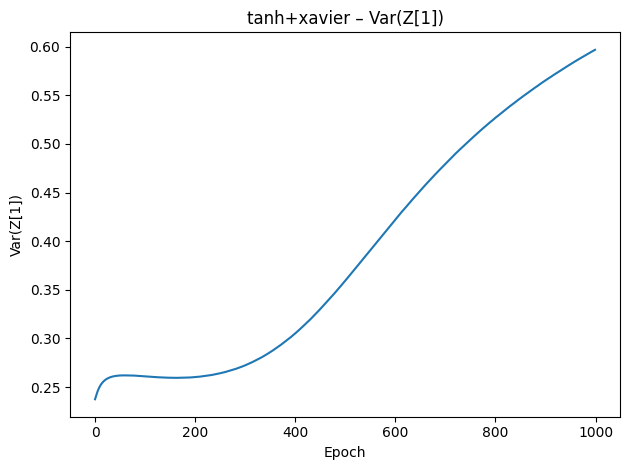

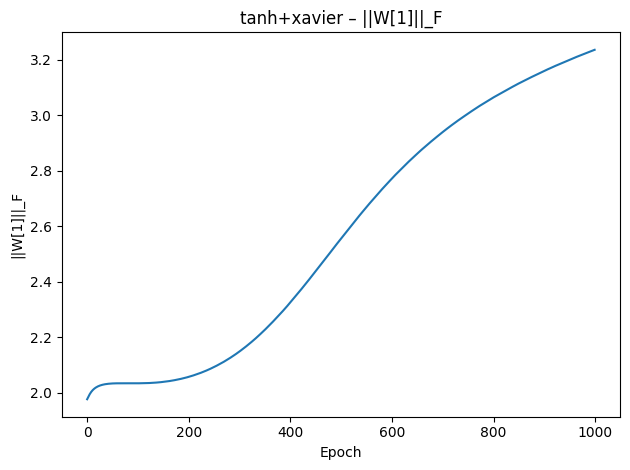

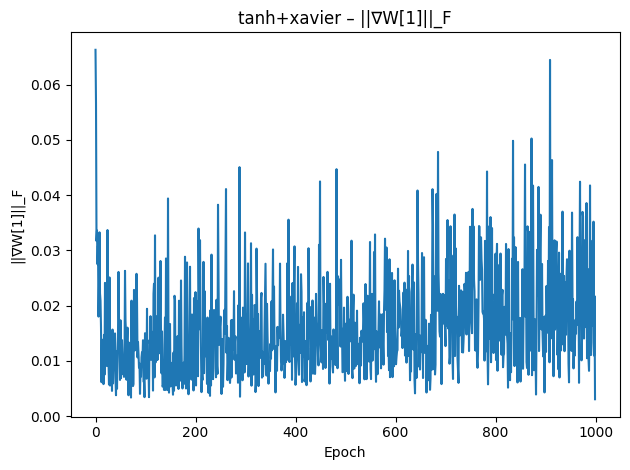

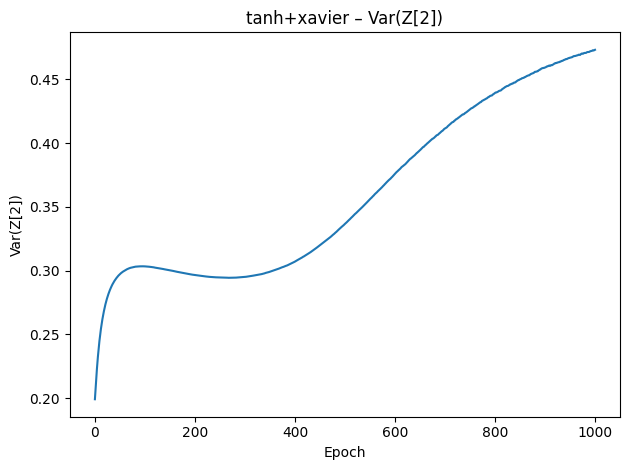

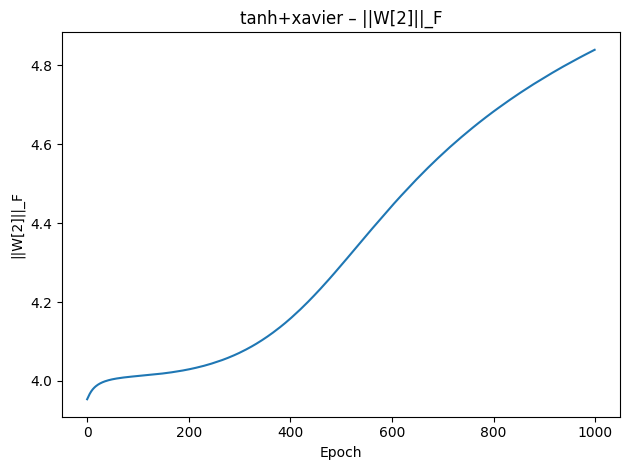

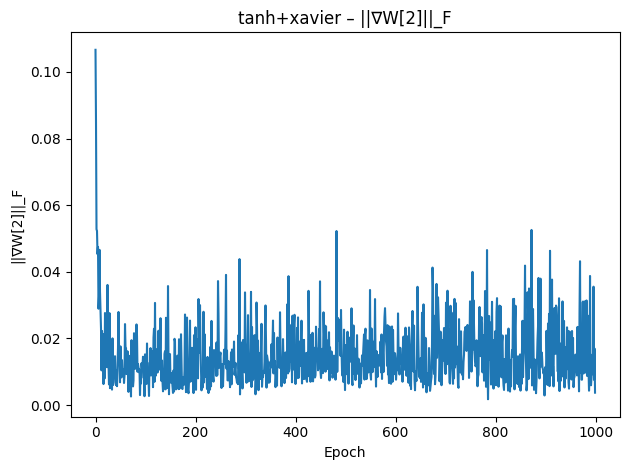

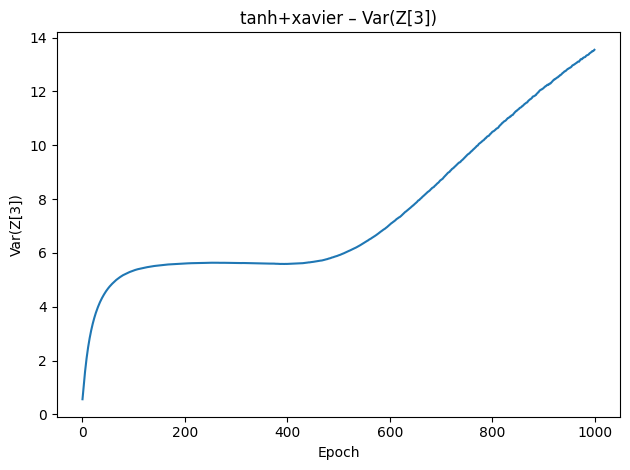

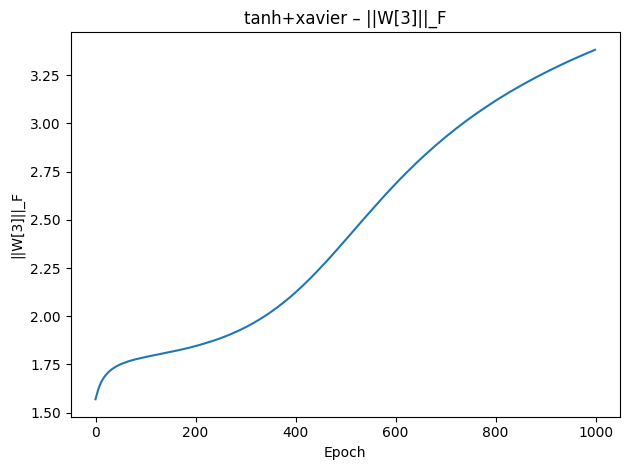

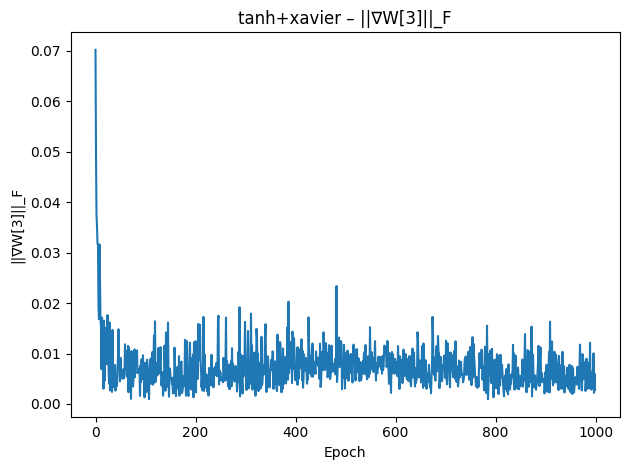

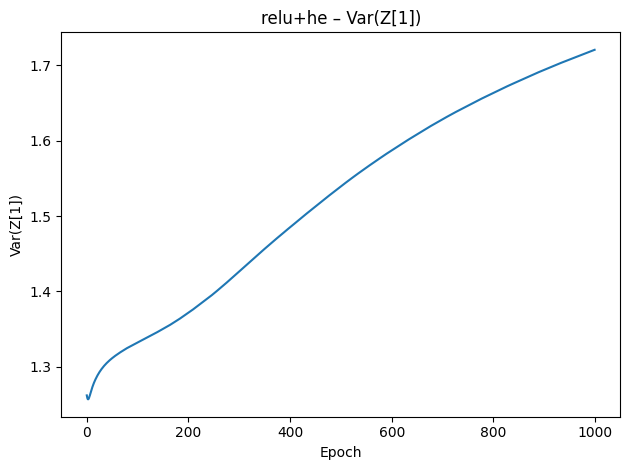

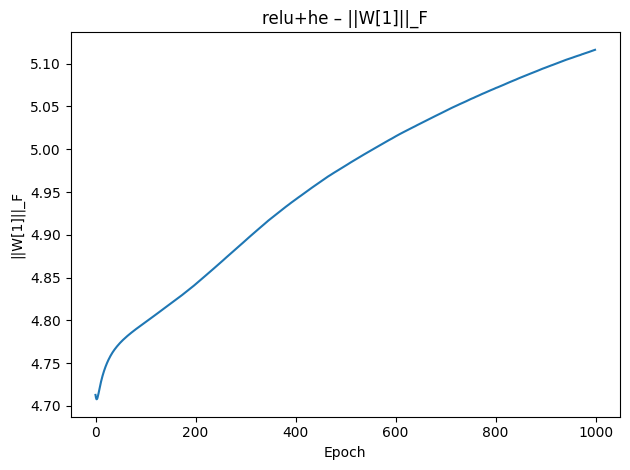

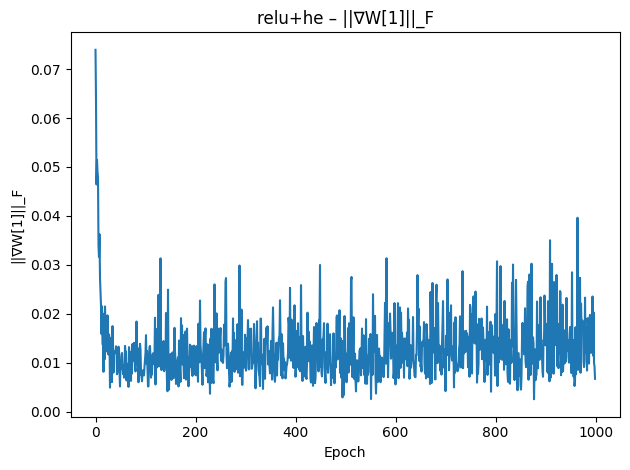

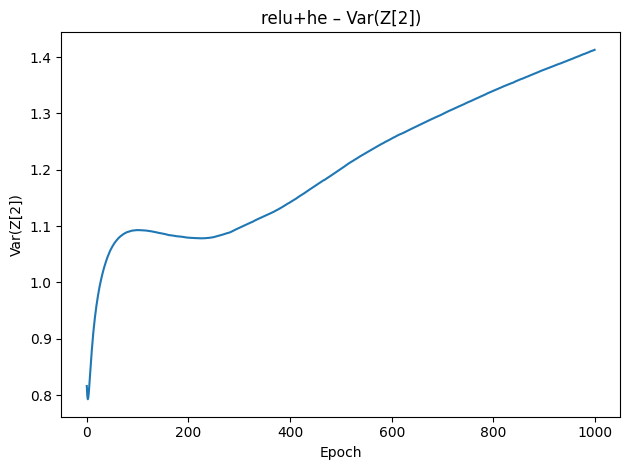

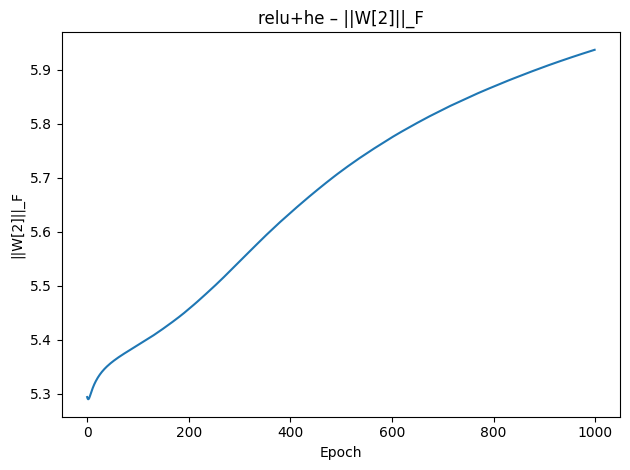

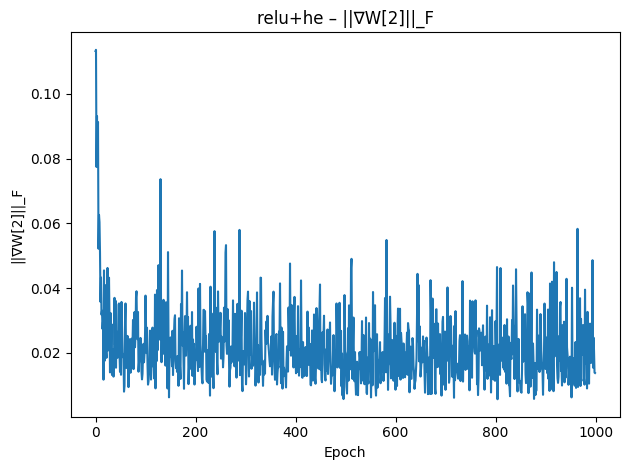

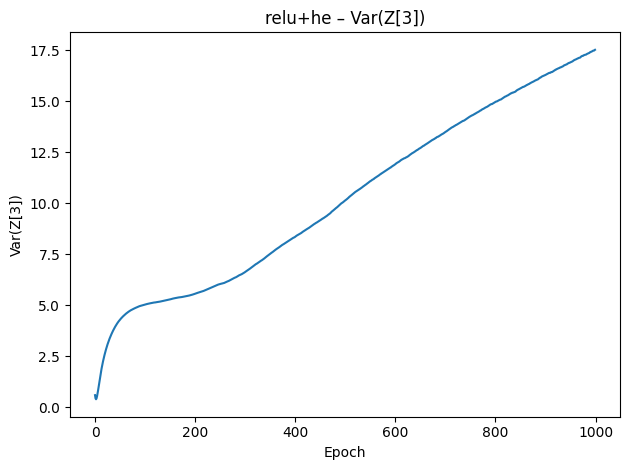

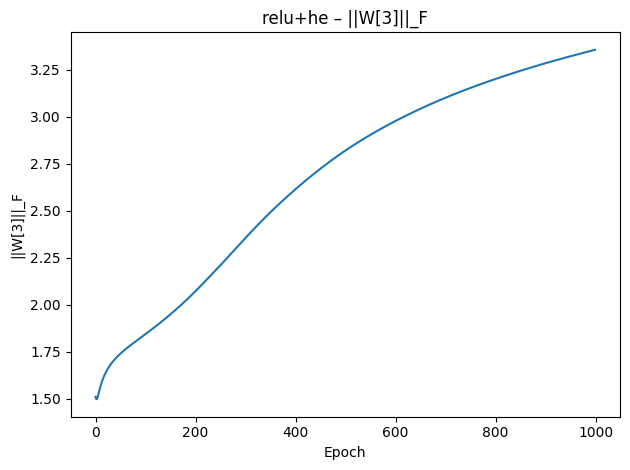

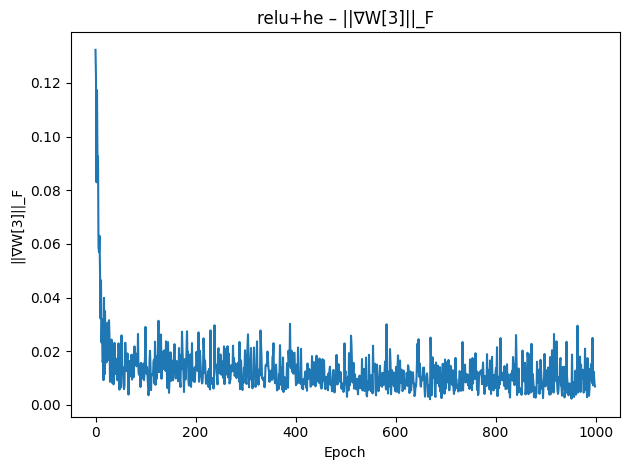

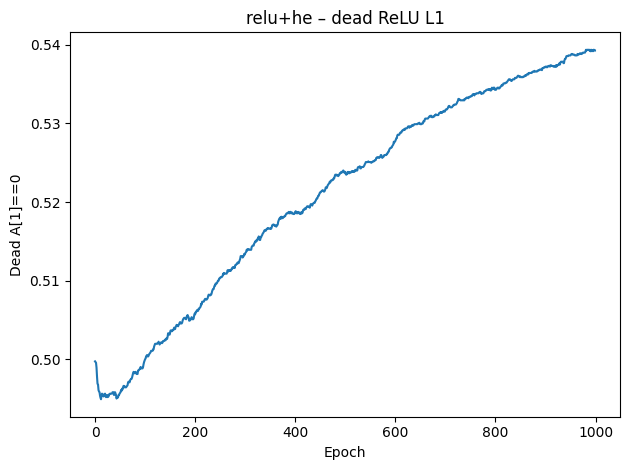

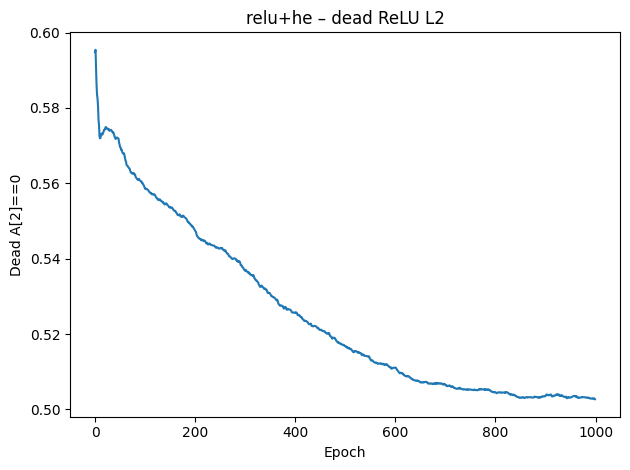

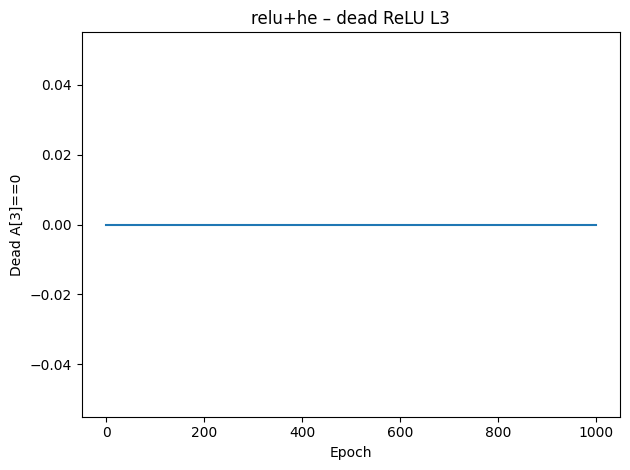

In [5]:

logs = {}
logs["tanh+xavier"] = train_eval_log(rng_seed=42, n_epochs=1000, lr=0.05, batch_size=64, act_kind="tanh", init_kind="xavier")
logs["relu+he"]     = train_eval_log(rng_seed=42, n_epochs=1000, lr=0.05, batch_size=64, act_kind="relu", init_kind="he")

for name in ["tanh+xavier", "relu+he"]:
    H = logs[name]["history"]
    for l in range(1,4):
        plot_series(H["Z_var"][l], "Epoch", f"Var(Z[{l}])", f"{name} – Var(Z[{l}])")
        plot_series(H["W_norms"][l], "Epoch", f"||W[{l}]||_F", f"{name} – ||W[{l}]||_F")
        plot_series(H["gW_norms"][l], "Epoch", f"||∇W[{l}]||_F", f"{name} – ||∇W[{l}]||_F")
    if H.get("dead_relu") is not None:
        for l in range(1,4):
            plot_series(H["dead_relu"][l], "Epoch", f"Dead A[{l}]==0", f"{name} – dead ReLU L{l}")


### Reproducibilidad (semillas)

acc_te tanh+xavier mean±std: 0.9620000000000001 0.002666666666666684
acc_te relu+he mean±std: 0.962 0.0026666666666666896


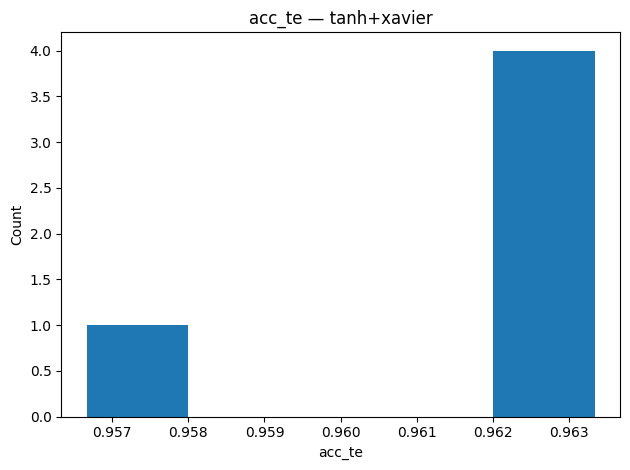

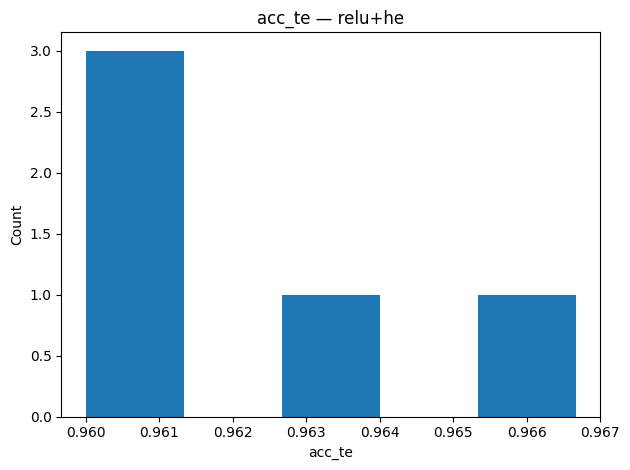

In [6]:

def seeds_study(N: int = 5, **train_kwargs):
    acc_te = []
    for s in range(N):
        res = train_eval_log(rng_seed=100+s, **train_kwargs)
        acc_te.append(res["history"]["acc_te"][-1])
    return np.array(acc_te)

accs_tanh = seeds_study(N=5, n_epochs=800, lr=0.05, batch_size=64, act_kind="tanh", init_kind="xavier")
accs_relu = seeds_study(N=5, n_epochs=800, lr=0.05, batch_size=64, act_kind="relu", init_kind="he")

print("acc_te tanh+xavier mean±std:", float(accs_tanh.mean()), float(accs_tanh.std()))
print("acc_te relu+he mean±std:", float(accs_relu.mean()), float(accs_relu.std()))
plot_hist(accs_tanh, bins=5, title="acc_te — tanh+xavier", xlabel="acc_te")
plot_hist(accs_relu, bins=5, title="acc_te — relu+he", xlabel="acc_te")


### LR Range Test

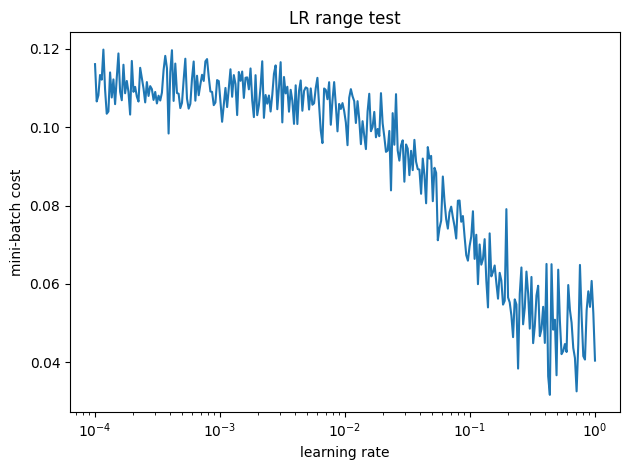

In [7]:

def lr_range_test(lr_start=1e-4, lr_end=1.0, n_iters=200, batch_size=64, act_kind="tanh", init_kind="xavier", rng_seed=123):
    rng = np.random.default_rng(rng_seed); X_tr, X_te, y_tr, y_te = build_dataset()
    params = init_params([2,16,16,1], rng, init_kind); acts, acts_p = make_acts([2,16,16,1], act_kind)
    iters = 0; costs = []; lrs = []; log_lr_start = np.log(lr_start); log_lr_end = np.log(lr_end)
    while iters < n_iters:
        for X_b, Y_b in iter_minibatches(X_tr, y_tr, batch_size, rng, shuffle=True):
            t = iters / max(n_iters - 1, 1); lr_t = float(np.exp(log_lr_start + t * (log_lr_end - log_lr_start)))
            A_b, cache_b = forward_propagation(X_b, params, acts, keep_probs=None, training=True)
            cost_b = compute_cost(A_b, Y_b, params=params, l2_lambda=0.0)
            grads_b = backward_propagation(Y_b, params, cache_b, acts_p, l2_lambda=0.0, keep_probs=None)
            params = update_parameters(params, grads_b, lr_t)
            costs.append(cost_b); lrs.append(lr_t); iters += 1
            if iters >= n_iters: break
    return np.array(lrs), np.array(costs)

lrs, costs = lr_range_test(n_iters=300)
plt.figure(); plt.plot(lrs, costs); plt.xscale("log"); plt.xlabel("learning rate"); plt.ylabel("mini-batch cost"); plt.title("LR range test"); plt.tight_layout(); plt.show()


### Dropout: invariancia y MC Dropout

Mean |A_train(do)-A_test| per layer: {1: 0.014208206587812177, 2: 0.022073125633965077, 3: 0.019759018194364097}


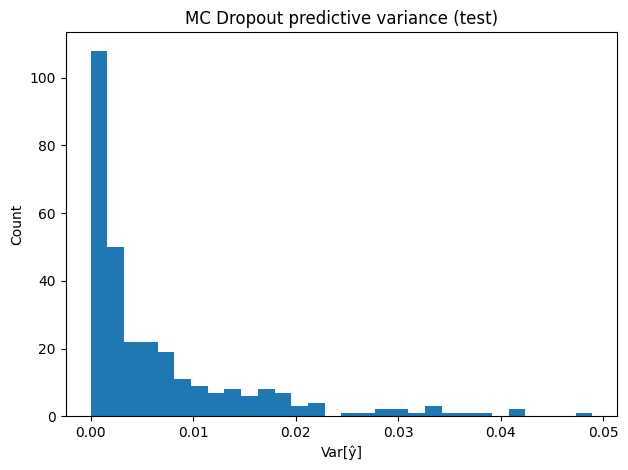

In [8]:

def dropout_expectation_check(params: LLayerParams, acts, X: Array, keep_probs: Mapping[int, float], K: int = 100):
    A_mean = {l: np.zeros((params.W[l].shape[0], X.shape[1])) for l in params.W.keys()}
    for _ in range(K):
        _, cache = forward_propagation(X, params, acts, keep_probs=keep_probs, training=True)
        for l in params.W.keys():
            A_mean[l] += cache["A"][l]
    for l in params.W.keys(): A_mean[l] /= K
    _, cache_det = forward_propagation(X, params, acts, keep_probs=None, training=False)
    diffs = {l: float(np.mean(np.abs(A_mean[l] - cache_det["A"][l]))) for l in params.W.keys()}
    return diffs

res_do = train_eval_log(rng_seed=321, n_epochs=800, lr=0.05, batch_size=64, act_kind="tanh", init_kind="xavier",
                        l2_lambda=0.0, keep_probs={1:0.9,2:0.9}, use_dropout=True)
X_tr, X_te, y_tr, y_te = build_dataset(); acts, _ = make_acts([2,16,16,1], "tanh")
diffs = dropout_expectation_check(res_do["params"], acts, X_tr, keep_probs={1:0.9,2:0.9}, K=50)
print("Mean |A_train(do)-A_test| per layer:", diffs)

def mc_dropout_predictive_variance(params: LLayerParams, acts, X: Array, keep_probs: Mapping[int, float], T: int = 30):
    preds = []
    for _ in range(T):
        A_L, _ = forward_propagation(X, params, acts, keep_probs=keep_probs, training=True)
        preds.append(A_L)
    P = np.stack(preds, axis=0); return np.mean(P, axis=0), np.var(P, axis=0)

mean_pred, var_pred = mc_dropout_predictive_variance(res_do["params"], acts, X_te, keep_probs={1:0.9,2:0.9}, T=30)
plot_hist(var_pred.ravel(), bins=30, title="MC Dropout predictive variance (test)", xlabel="Var[ŷ]")


### Gradient Check

In [9]:

def gradient_check_single_weight(layer_sizes=[2,3,1], act_kind="tanh", init_kind="xavier", n_samples=5, eps=1e-5, rng_seed=202):
    rng = np.random.default_rng(rng_seed)
    X, Y = make_moons(n_samples=n_samples, noise=0.1, random_state=0)
    scaler = StandardScaler().fit(X); X = scaler.transform(X)
    X = X.T.astype(np.float64); Y = Y.reshape(1,-1).astype(np.float64)
    params = init_params(layer_sizes, rng, init_kind); acts, acts_p = make_acts(layer_sizes, act_kind)
    A, cache = forward_propagation(X, params, acts, keep_probs=None, training=False)
    grads = backward_propagation(Y, params, cache, acts_p, l2_lambda=0.0, keep_probs=None)
    l,i,j = 1,0,0
    def cloneW(W): return {k:v.copy() for k,v in W.items()}
    Wp = cloneW(params.W); Wp[l][i,j] += eps
    Ap,_ = forward_propagation(X, LLayerParams(W=Wp, b=params.b), acts, keep_probs=None, training=False)
    Jp = compute_cost(Ap, Y, params=LLayerParams(W=Wp, b=params.b), l2_lambda=0.0)
    Wm = cloneW(params.W); Wm[l][i,j] -= eps
    Am,_ = forward_propagation(X, LLayerParams(W=Wm, b=params.b), acts, keep_probs=None, training=False)
    Jm = compute_cost(Am, Y, params=LLayerParams(W=Wm, b=params.b), l2_lambda=0.0)
    g_num = (Jp - Jm) / (2*eps); g_ana = grads["dW"][l][i,j]
    rel_err = abs(g_num - g_ana) / max(1.0, abs(g_num) + abs(g_ana))
    return dict(g_num=g_num, g_ana=float(g_ana), rel_err=float(rel_err))

chk = gradient_check_single_weight(); print("Gradient check:", chk)


Gradient check: {'g_num': -0.0002170742495477551, 'g_ana': -0.00021707424941001607, 'rel_err': 1.3773902266152327e-13}
